### Task 1: Designing a Heuristic for a Warehouse Robot

Heuristic Values
----------------
Receiving_Area: 9.22
Storage_A: 7.07
Storage_B: 6.32
Sorting_Area: 5.00
Inspection_Area: 2.24
Packing_Station: 0.00

Minimum cost path:
Receiving_Area -> Storage_A -> Sorting_Area -> Packing_Station
Total cost: 9.40
Receiving_Area -> Storage_A: True
Receiving_Area -> Storage_B: True
Storage_A -> Sorting_Area: True
Storage_B -> Inspection_Area: True
Storage_B -> Sorting_Area: True
Sorting_Area -> Inspection_Area: True
Sorting_Area -> Packing_Station: True
Inspection_Area -> Packing_Station: False


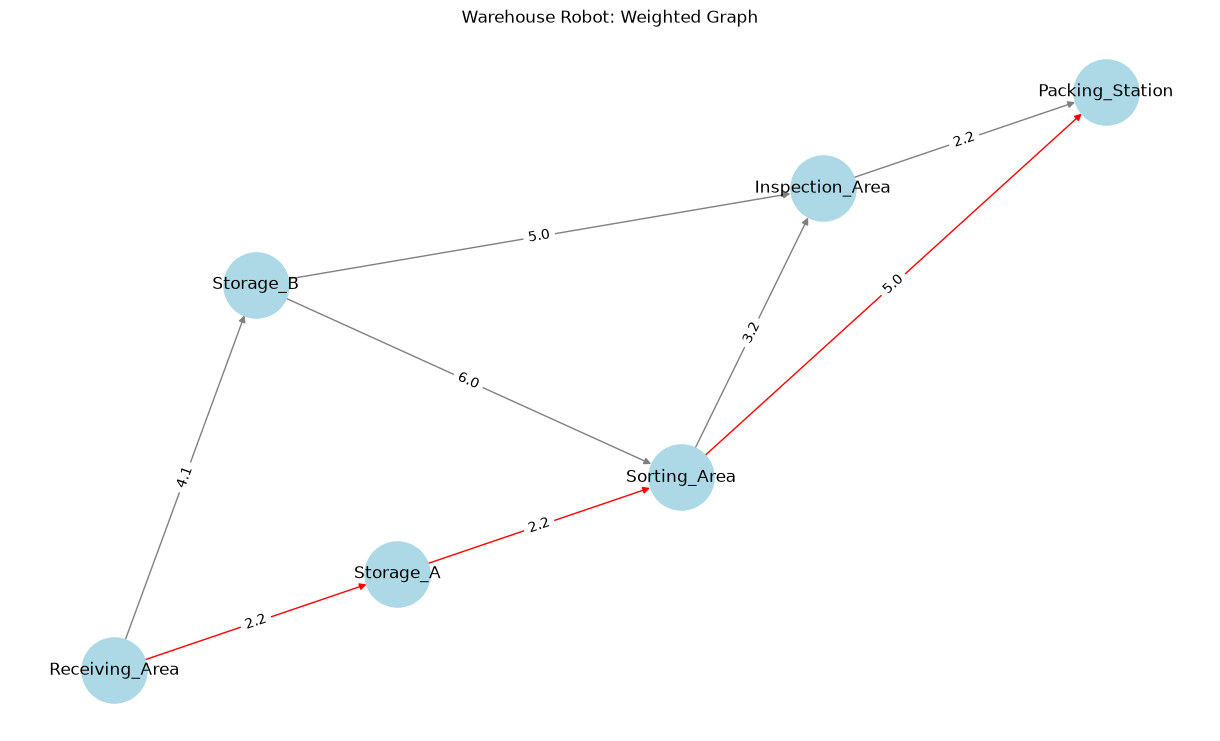

In [1]:
import math
import networkx as nx
import matplotlib.pyplot as plt

locations = {'Receiving_Area': (0, 0), 'Storage_A': (2, 1), 'Storage_B': (1, 4), 'Sorting_Area': (4, 2), 'Inspection_Area': (5, 5), 'Packing_Station': (7, 6)}
warehouse_graph = {'Receiving_Area': {'Storage_A': 2.2, 'Storage_B': 4.1}, 'Storage_A': {'Sorting_Area': 2.2}, 'Storage_B': {'Inspection_Area': 5.0, 'Sorting_Area': 6.0}, 'Sorting_Area': {'Inspection_Area': 3.2, 'Packing_Station': 5.0}, 'Inspection_Area': {'Packing_Station': 2.2}, 'Packing_Station': {}}

def heuristic(current, goal):
    return math.dist(locations[current], locations[goal])

goal = 'Packing_Station'
print('Heuristic Values')
print('----------------')
for location in locations:
    print(f'{location}: {heuristic(location, goal):.2f}')

G = nx.DiGraph()
for node, neighbors in warehouse_graph.items():
    for neighbor, cost in neighbors.items():
        G.add_edge(node, neighbor, weight=cost)
solution_path = nx.shortest_path(G, 'Receiving_Area', 'Packing_Station', weight='weight')
solution_cost = nx.shortest_path_length(G, 'Receiving_Area', 'Packing_Station', weight='weight')
print('\nMinimum cost path:')
print(' -> '.join(solution_path))
print(f'Total cost: {solution_cost:.2f}')
for node in warehouse_graph:
    for neighbor, cost in warehouse_graph[node].items():
        print(f'{node} -> {neighbor}: {heuristic(node, goal) <= cost + heuristic(neighbor, goal)}')
pos = locations
plt.figure(figsize=(12, 7))
colors = ['red' if (u, v) in zip(solution_path, solution_path[1:]) else 'gray' for u, v in G.edges()]
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2200, edge_color=colors, arrows=True)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, 'weight'))
plt.title('Warehouse Robot: Weighted Graph')
plt.axis('off')
plt.show()

Euclidean distance is suitable because the locations have 2D coordinates and it estimates the remaining movement cost without overestimating it.

### Task 2: Greedy Best-First Search for Airport Baggage Handling

GBFS
Expansion order: Baggage_Area -> Checkpoint -> Terminal_Hall -> Departure_Gate
Solution path: Baggage_Area -> Checkpoint -> Terminal_Hall -> Departure_Gate
Total path cost: 12.30


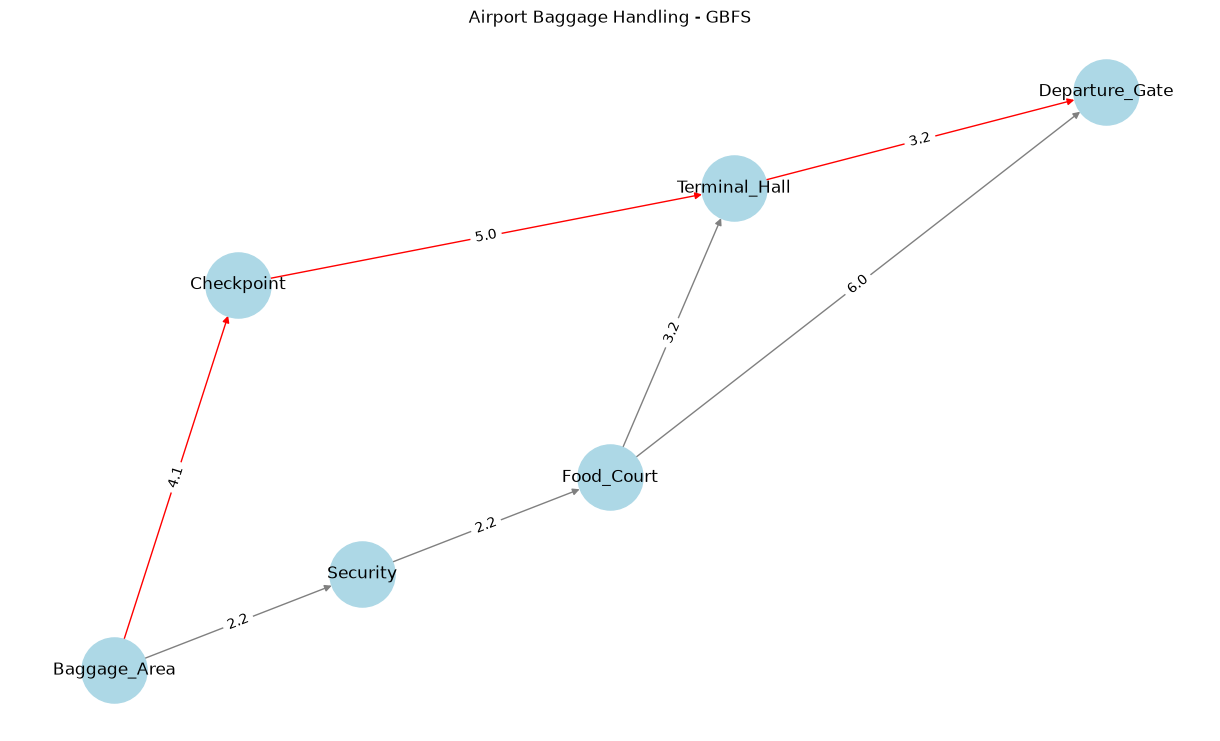

In [2]:
import math
import heapq
import networkx as nx
import matplotlib.pyplot as plt

locations = {'Baggage_Area': (0, 0), 'Security': (2, 1), 'Checkpoint': (1, 4), 'Food_Court': (4, 2), 'Terminal_Hall': (5, 5), 'Departure_Gate': (8, 6)}
airport_graph = {'Baggage_Area': {'Security': 2.2, 'Checkpoint': 4.1}, 'Security': {'Food_Court': 2.2}, 'Checkpoint': {'Terminal_Hall': 5.0}, 'Food_Court': {'Terminal_Hall': 3.2, 'Departure_Gate': 6.0}, 'Terminal_Hall': {'Departure_Gate': 3.2}, 'Departure_Gate': {}}

def heuristic(current, goal):
    return math.dist(locations[current], locations[goal])

def greedy_best_first_search(start, goal, graph):
    frontier = [(heuristic(start, goal), start)]
    came_from = {start: None}
    visited = set()
    expansion_order = []
    while frontier:
        _, current = heapq.heappop(frontier)
        if current in visited:
            continue
        visited.add(current)
        expansion_order.append(current)
        if current == goal:
            break
        for neighbor in graph[current]:
            if neighbor not in visited:
                came_from.setdefault(neighbor, current)
                heapq.heappush(frontier, (heuristic(neighbor, goal), neighbor))
    path = []
    current = goal
    while current is not None:
        path.append(current)
        current = came_from[current]
    path.reverse()
    cost = sum(graph[a][b] for a, b in zip(path, path[1:]))
    return path, cost, expansion_order

path, total_cost, expansion_order = greedy_best_first_search('Baggage_Area', 'Departure_Gate', airport_graph)
print('GBFS')
print('Expansion order:', ' -> '.join(expansion_order))
print('Solution path:', ' -> '.join(path))
print(f'Total path cost: {total_cost:.2f}')
G = nx.DiGraph()
for node, neighbors in airport_graph.items():
    for neighbor, cost in neighbors.items():
        G.add_edge(node, neighbor, weight=cost)
plt.figure(figsize=(12, 7))
colors = ['red' if (u, v) in zip(path, path[1:]) else 'gray' for u, v in G.edges()]
nx.draw(G, locations, with_labels=True, node_color='lightblue', node_size=2200, edge_color=colors, arrows=True)
nx.draw_networkx_edge_labels(G, locations, edge_labels=nx.get_edge_attributes(G, 'weight'))
plt.title('Airport Baggage Handling - GBFS')
plt.axis('off')
plt.show()

GBFS expands the node with the smallest Euclidean distance to the Departure Gate.

### Task 3: A* Search for Emergency Supply Robot

A* Search
Expansion order: Pharmacy -> Main_Corridor -> Nursing_Station -> Emergency_Ward
Solution path: Pharmacy -> Main_Corridor -> Nursing_Station -> Emergency_Ward
Total path cost: 10.40

A* Node Information
Node                      g(n)      h(n)      f(n)
Pharmacy                  0.00     10.00     10.00
Main_Corridor             2.20      7.81     10.01
Nursing_Station           4.40      5.66     10.06
Emergency_Ward           10.40      0.00     10.40


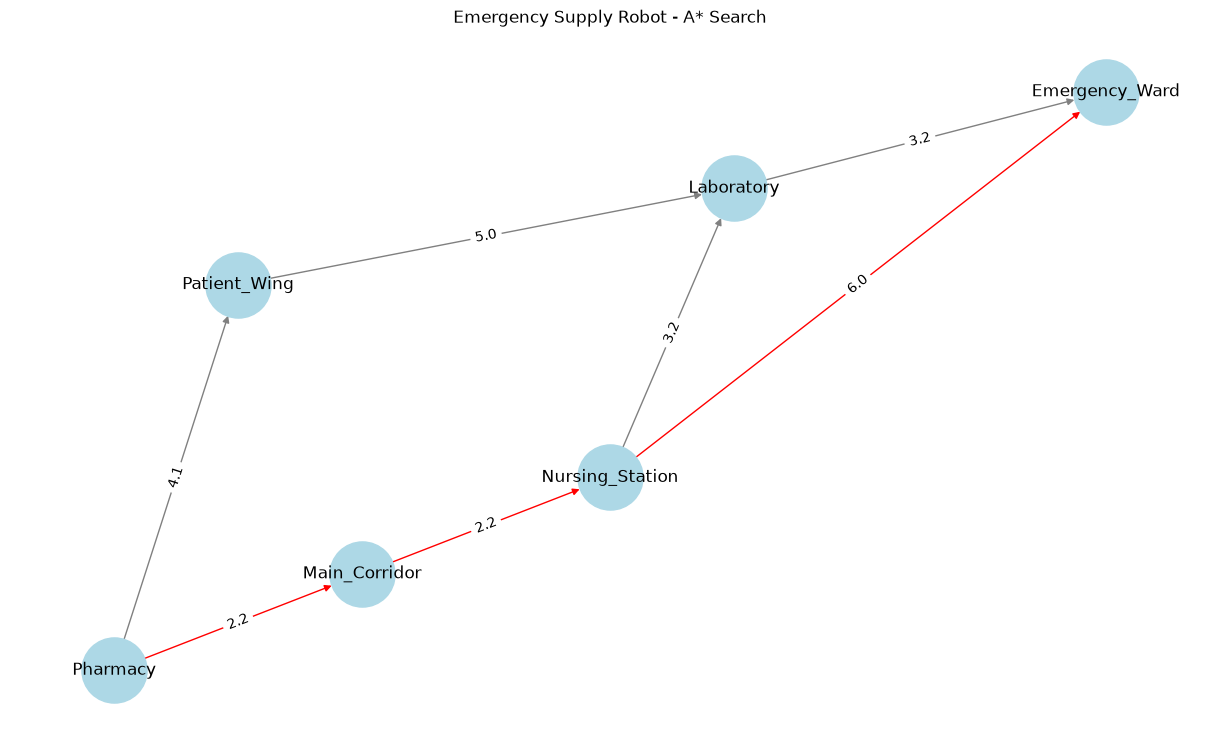

In [3]:
import math
import heapq
import networkx as nx
import matplotlib.pyplot as plt

locations = {'Pharmacy': (0, 0), 'Main_Corridor': (2, 1), 'Patient_Wing': (1, 4), 'Nursing_Station': (4, 2), 'Laboratory': (5, 5), 'Emergency_Ward': (8, 6)}
hospital_graph = {'Pharmacy': {'Main_Corridor': 2.2, 'Patient_Wing': 4.1}, 'Main_Corridor': {'Nursing_Station': 2.2}, 'Patient_Wing': {'Laboratory': 5.0}, 'Nursing_Station': {'Laboratory': 3.2, 'Emergency_Ward': 6.0}, 'Laboratory': {'Emergency_Ward': 3.2}, 'Emergency_Ward': {}}

def heuristic(current, goal):
    return math.dist(locations[current], locations[goal])

def reconstruct_path(came_from, current):
    path = []
    while current is not None:
        path.append(current)
        current = came_from.get(current)
    return path[::-1]

def a_star_search(start, goal, graph):
    frontier = [(heuristic(start, goal), start)]
    came_from = {start: None}
    g_cost = {start: 0}
    expansion_order = []
    while frontier:
        _, current = heapq.heappop(frontier)
        if current in expansion_order:
            continue
        expansion_order.append(current)
        if current == goal:
            break
        for neighbor, cost in graph[current].items():
            new_cost = g_cost[current] + cost
            if new_cost < g_cost.get(neighbor, float('inf')):
                g_cost[neighbor] = new_cost
                came_from[neighbor] = current
                heapq.heappush(frontier, (new_cost + heuristic(neighbor, goal), neighbor))
    return reconstruct_path(came_from, goal), g_cost[goal], expansion_order, g_cost

path, total_cost, expansion_order, g_cost = a_star_search('Pharmacy', 'Emergency_Ward', hospital_graph)
goal = 'Emergency_Ward'
print('A* Search')
print('Expansion order:', ' -> '.join(expansion_order))
print('Solution path:', ' -> '.join(path))
print(f'Total path cost: {total_cost:.2f}')
print('\nA* Node Information')
print(f"{'Node':20s}{'g(n)':>10s}{'h(n)':>10s}{'f(n)':>10s}")
for node in expansion_order:
    h = heuristic(node, goal)
    print(f'{node:20s}{g_cost[node]:10.2f}{h:10.2f}{g_cost[node] + h:10.2f}')
G = nx.DiGraph()
for node, neighbors in hospital_graph.items():
    for neighbor, cost in neighbors.items():
        G.add_edge(node, neighbor, weight=cost)
plt.figure(figsize=(12, 7))
colors = ['red' if (u, v) in zip(path, path[1:]) else 'gray' for u, v in G.edges()]
nx.draw(G, locations, with_labels=True, node_color='lightblue', node_size=2200, edge_color=colors, arrows=True)
nx.draw_networkx_edge_labels(G, locations, edge_labels=nx.get_edge_attributes(G, 'weight'))
plt.title('Emergency Supply Robot - A* Search')
plt.axis('off')
plt.show()

A* considers both the cost already travelled and the estimated remaining cost, unlike GBFS.

### Task 4: Weighted A* for Autonomous Delivery Drone

 Weight                                                Solution Path  Total Cost  Nodes Expanded                                                        Expansion Order
    1.0 Distribution_Center -> Zone_A -> Zone_C -> Customer_Building        10.4               5 Distribution_Center -> Zone_A -> Zone_C -> Zone_B -> Customer_Building
    1.5 Distribution_Center -> Zone_A -> Zone_C -> Customer_Building        10.4               4           Distribution_Center -> Zone_A -> Zone_C -> Customer_Building
    2.0 Distribution_Center -> Zone_B -> Zone_D -> Customer_Building        11.2               4           Distribution_Center -> Zone_B -> Zone_D -> Customer_Building
    3.0 Distribution_Center -> Zone_B -> Zone_D -> Customer_Building        11.2               4           Distribution_Center -> Zone_B -> Zone_D -> Customer_Building


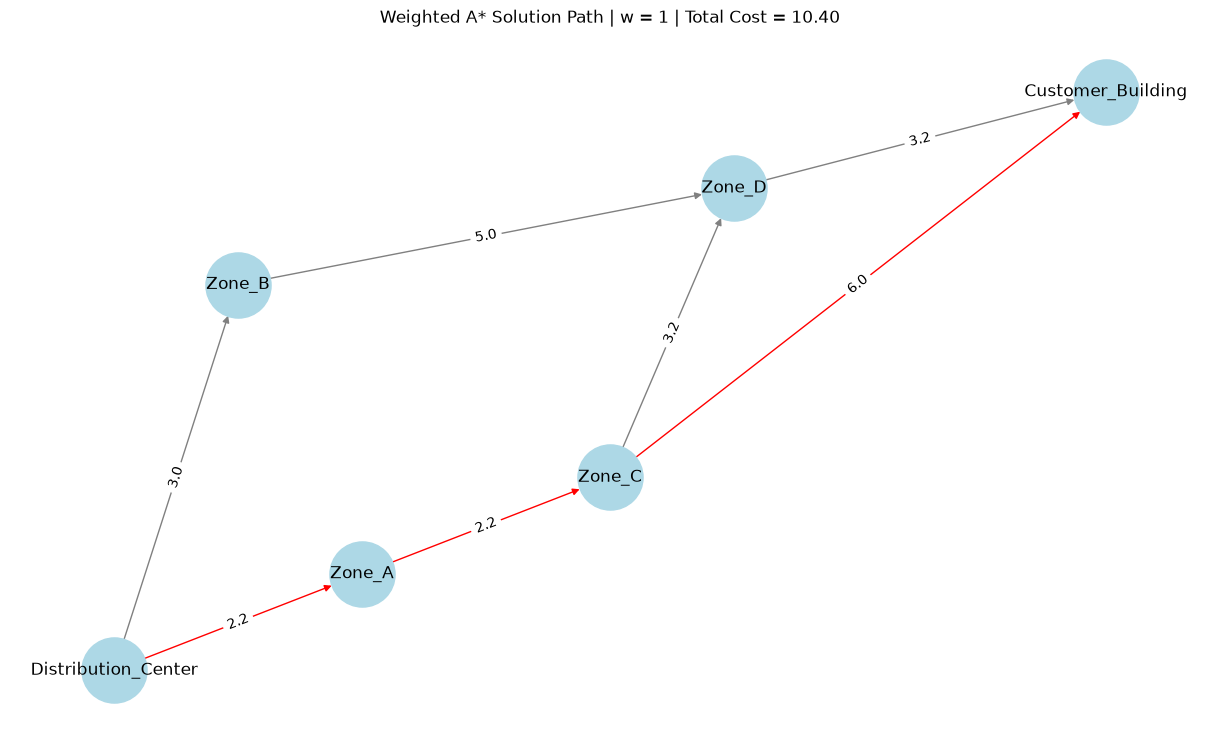

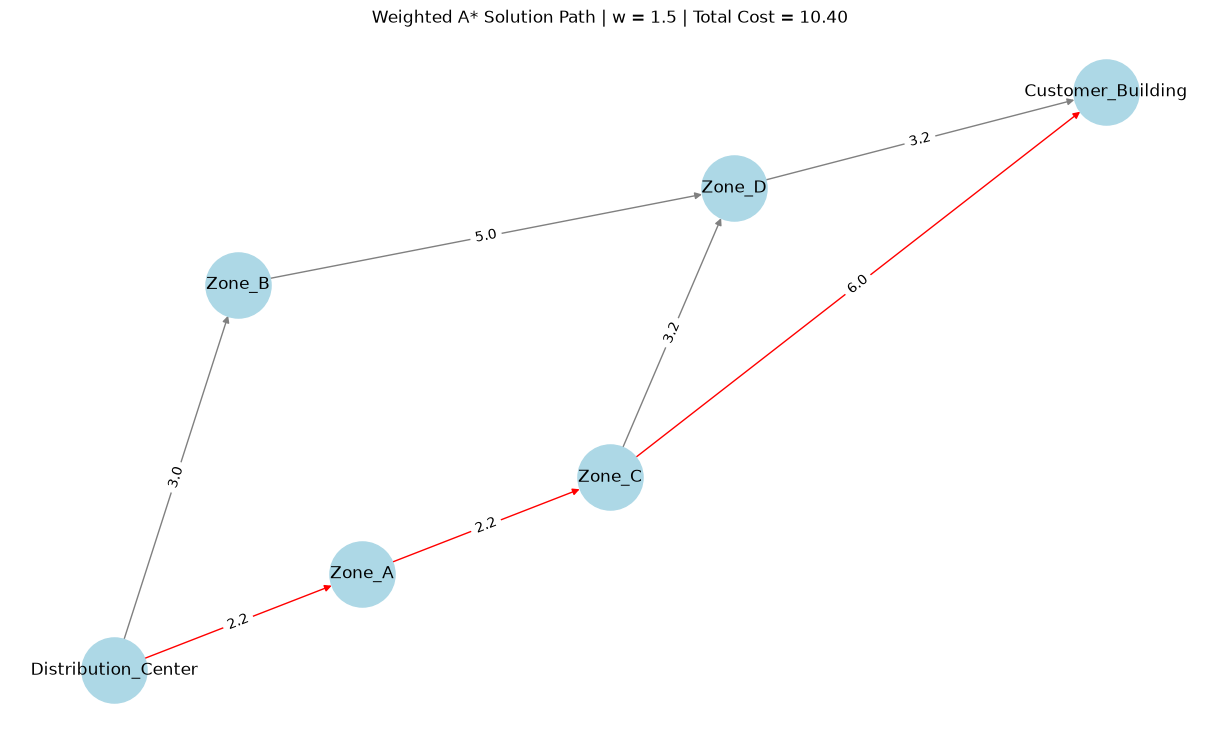

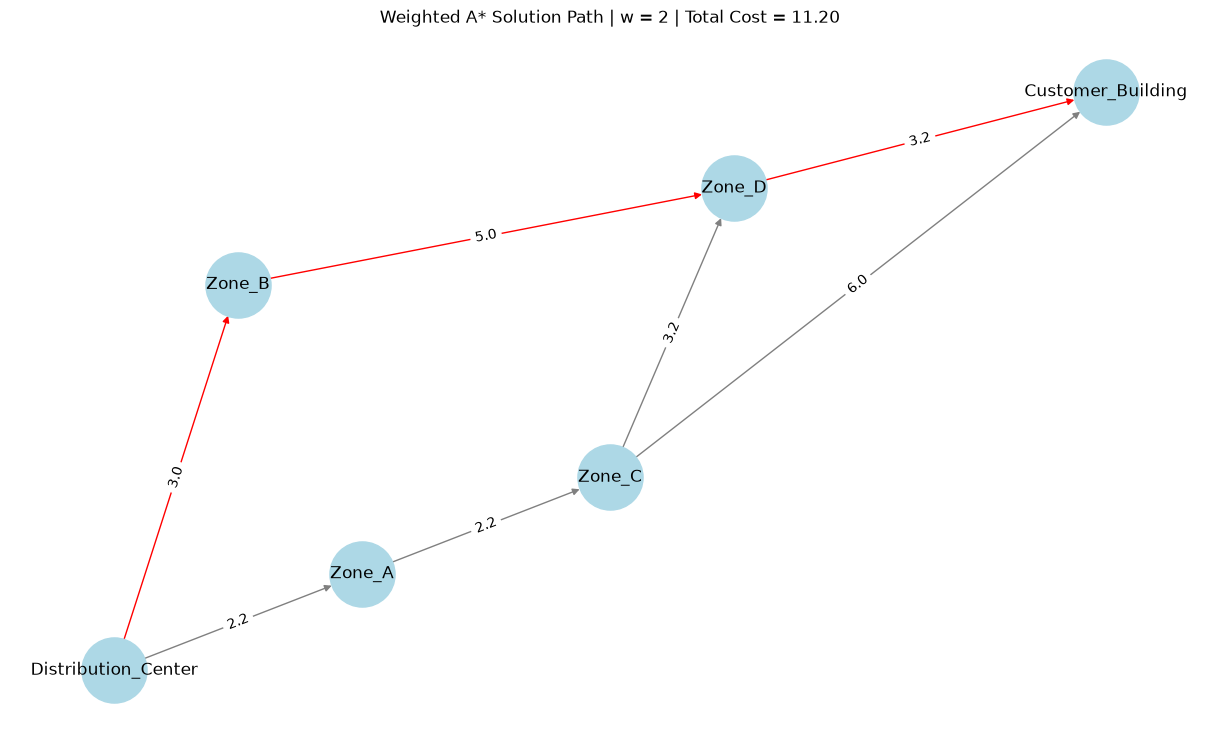

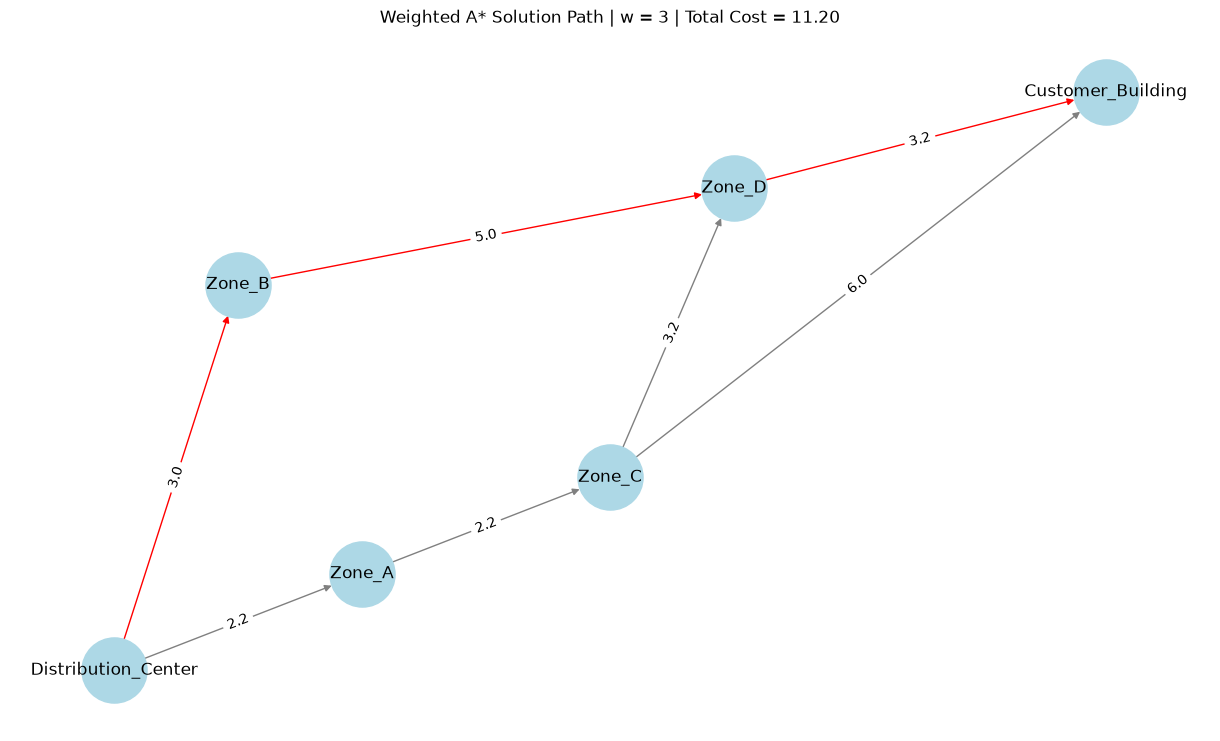

In [4]:
import math
import heapq
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

locations = {'Distribution_Center': (0, 0), 'Zone_A': (2, 1), 'Zone_B': (1, 4), 'Zone_C': (4, 2), 'Zone_D': (5, 5), 'Customer_Building': (8, 6)}
graph = {'Distribution_Center': {'Zone_A': 2.2, 'Zone_B': 3.0}, 'Zone_A': {'Zone_C': 2.2}, 'Zone_B': {'Zone_D': 5.0}, 'Zone_C': {'Zone_D': 3.2, 'Customer_Building': 6.0}, 'Zone_D': {'Customer_Building': 3.2}, 'Customer_Building': {}}

def heuristic(node, goal):
    return math.dist(locations[node], locations[goal])

def weighted_a_star(start, goal, graph, weight):
    frontier = [(weight * heuristic(start, goal), start)]
    came_from = {start: None}
    g_cost = {start: 0}
    expansion_order = []
    while frontier:
        _, current = heapq.heappop(frontier)
        if current in expansion_order:
            continue
        expansion_order.append(current)
        if current == goal:
            break
        for neighbor, cost in graph[current].items():
            new_cost = g_cost[current] + cost
            if new_cost < g_cost.get(neighbor, float('inf')):
                g_cost[neighbor] = new_cost
                came_from[neighbor] = current
                heapq.heappush(frontier, (new_cost + weight * heuristic(neighbor, goal), neighbor))
    path = []
    current = goal
    while current is not None:
        path.append(current)
        current = came_from[current]
    return path[::-1], g_cost[goal], expansion_order

start = 'Distribution_Center'
goal = 'Customer_Building'
weights = [1, 1.5, 2, 3]
results = []
for w in weights:
    path, cost, expansion_order = weighted_a_star(start, goal, graph, w)
    results.append({'Weight': w, 'Solution Path': ' -> '.join(path), 'Total Cost': round(cost, 2), 'Nodes Expanded': len(expansion_order), 'Expansion Order': ' -> '.join(expansion_order)})
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
G = nx.DiGraph()
for node, neighbors in graph.items():
    for neighbor, cost in neighbors.items():
        G.add_edge(node, neighbor, weight=cost)
for w in weights:
    path, cost, expansion_order = weighted_a_star(start, goal, graph, w)
    plt.figure(figsize=(12, 7))
    colors = ['red' if (u, v) in zip(path, path[1:]) else 'gray' for u, v in G.edges()]
    nx.draw(G, locations, with_labels=True, node_color='lightblue', node_size=2200, edge_color=colors, arrows=True)
    nx.draw_networkx_edge_labels(G, locations, edge_labels=nx.get_edge_attributes(G, 'weight'))
    plt.title(f'Weighted A* Solution Path | w = {w} | Total Cost = {cost:.2f}')
    plt.axis('off')
    plt.show()

Increasing w gives more importance to the heuristic, which can reduce expansions but may return a higher-cost path than normal A*.

GBFS: Current_Location -> Junction_A -> Junction_C -> Charging_Central Cost: 8.40 Expanded: Current_Location -> Junction_A -> Junction_C -> Charging_Central
A*: Current_Location -> Junction_A -> Junction_C -> Charging_Central Cost: 8.40 Expanded: Current_Location -> Junction_A -> Junction_C -> Charging_Central
                 Measure                                                             GBFS                                                               A*
Charging station reached                                                 Charging_Central                                                 Charging_Central
           Solution path Current_Location -> Junction_A -> Junction_C -> Charging_Central Current_Location -> Junction_A -> Junction_C -> Charging_Central
         Total path cost                                                              8.4                                                              8.4
Number of nodes expanded                                            

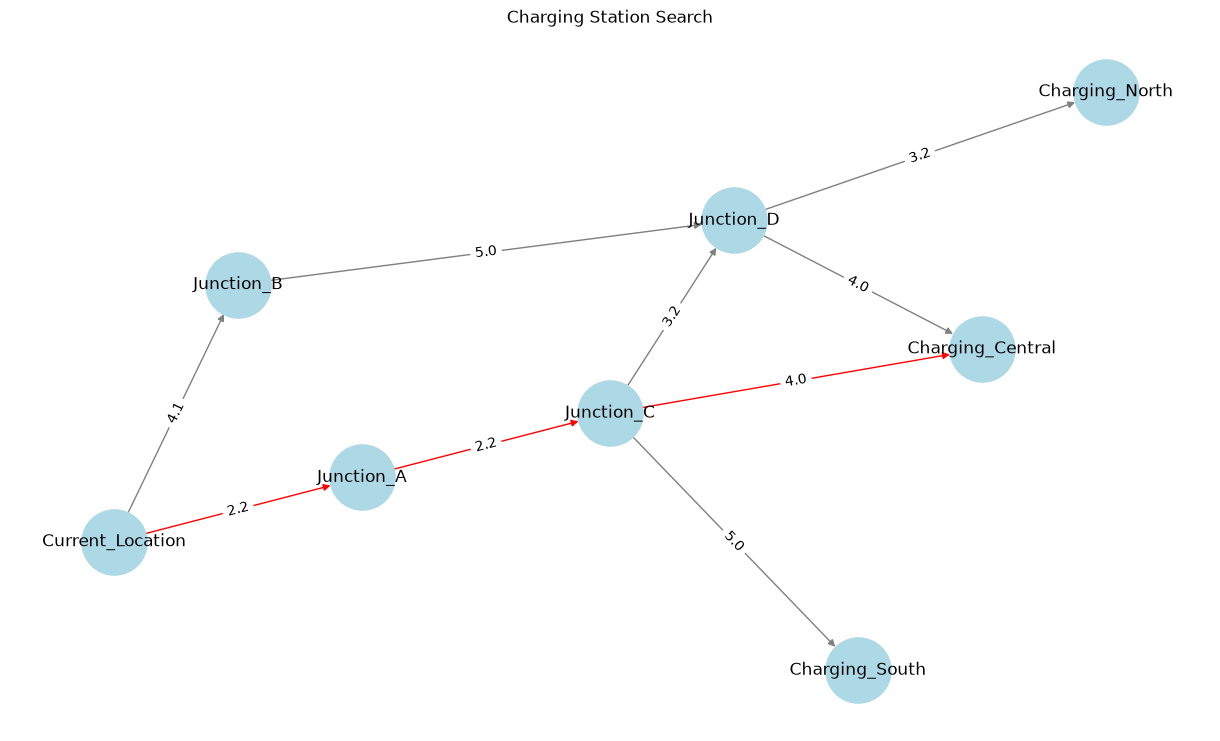

In [5]:
import math
import heapq
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

locations = {'Current_Location': (0, 0), 'Junction_A': (2, 1), 'Junction_B': (1, 4), 'Junction_C': (4, 2), 'Junction_D': (5, 5), 'Charging_North': (8, 7), 'Charging_Central': (7, 3), 'Charging_South': (6, -2)}
graph = {'Current_Location': {'Junction_A': 2.2, 'Junction_B': 4.1}, 'Junction_A': {'Junction_C': 2.2}, 'Junction_B': {'Junction_D': 5.0}, 'Junction_C': {'Junction_D': 3.2, 'Charging_Central': 4.0, 'Charging_South': 5.0}, 'Junction_D': {'Charging_North': 3.2, 'Charging_Central': 4.0}, 'Charging_North': {}, 'Charging_Central': {}, 'Charging_South': {}}
stations = {'Charging_North', 'Charging_Central', 'Charging_South'}

def heuristic(node):
    return min(math.dist(locations[node], locations[station]) for station in stations)

def search(start, use_cost):
    frontier = [(heuristic(start), 0, start)]
    came_from = {start: None}
    g_cost = {start: 0}
    expanded = []
    while frontier:
        _, _, current = heapq.heappop(frontier)
        if current in expanded:
            continue
        expanded.append(current)
        if current in stations:
            path = []
            node = current
            while node is not None:
                path.append(node)
                node = came_from[node]
            return path[::-1], g_cost[current], expanded
        for neighbor, edge_cost in graph[current].items():
            new_cost = g_cost[current] + edge_cost
            if new_cost < g_cost.get(neighbor, float('inf')):
                g_cost[neighbor] = new_cost
                came_from[neighbor] = current
                priority = new_cost + heuristic(neighbor) if use_cost else heuristic(neighbor)
                heapq.heappush(frontier, (priority, new_cost, neighbor))

gbfs_path, gbfs_cost, gbfs_expansion = search('Current_Location', False)
astar_path, astar_cost, astar_expansion = search('Current_Location', True)
print('GBFS:', ' -> '.join(gbfs_path), f'Cost: {gbfs_cost:.2f}', 'Expanded:', ' -> '.join(gbfs_expansion))
print('A*:', ' -> '.join(astar_path), f'Cost: {astar_cost:.2f}', 'Expanded:', ' -> '.join(astar_expansion))
comparison = pd.DataFrame({'Measure': ['Charging station reached', 'Solution path', 'Total path cost', 'Number of nodes expanded'], 'GBFS': [gbfs_path[-1], ' -> '.join(gbfs_path), round(gbfs_cost, 2), len(gbfs_expansion)], 'A*': [astar_path[-1], ' -> '.join(astar_path), round(astar_cost, 2), len(astar_expansion)]})
print(comparison.to_string(index=False))
G = nx.DiGraph()
for node, neighbors in graph.items():
    for neighbor, cost in neighbors.items():
        G.add_edge(node, neighbor, weight=cost)
plt.figure(figsize=(12, 7))
colors = ['red' if (u, v) in zip(astar_path, astar_path[1:]) else 'gray' for u, v in G.edges()]
nx.draw(G, locations, with_labels=True, node_color='lightblue', node_size=2200, edge_color=colors, arrows=True)
nx.draw_networkx_edge_labels(G, locations, edge_labels=nx.get_edge_attributes(G, 'weight'))
plt.title('Charging Station Search')
plt.axis('off')
plt.show()

GBFS uses only the nearest-station estimate, while A* also considers the cost already travelled and can choose a cheaper route.